In [1]:
# This file is a jupytext-paired Python script export of
# `binary_thinking_simulation_solution.ipynb`. The canonical artifact for learners is
# the notebook (.ipynb); this script is provided for code review and `git diff`
# readability. Run `jupytext --sync` to keep the two in lockstep after edits.

# When "Probably" Isn't the Same as "Definitely" (SOLUTION)

## Scenario

WaveForm, a fictional music streaming platform, runs genre-focused promotion campaigns each
season. Their editorial team uses a simple rule: if a genre's hit rate looks above 50%, run
a campaign; otherwise skip it.

You'll use real Spotify track data to measure what genre hit rates actually look like,
simulate what that 50% rule costs compared to a strategy that uses the full probability,
and quantify the certainty illusion — the gap between "above 50% so it'll work" and
what actually happens.

## What this notebook delivers

1. Real genre hit rates derived from Spotify track data.
2. The break-even hit rate from the payoff structure.
3. Two simulated strategies compared over 2,000 Monte Carlo seasons.
4. A measurement of the certainty illusion for genres the binary strategy runs.
5. A takeaway connecting the simulation to the general problem of rounding probabilities.

The deliverable stops at the analytical layer. It does not produce a stakeholder recommendation.

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../binary-thinking-simulation-starter/data/spotify_tracks_sample.csv"

HIT_THRESHOLD = 50      # Spotify popularity ≥ this = "hit"
NET_GAIN_K = 15         # net gain per campaign if track hits ($K)
COST_K = 8              # cost per campaign if track misses ($K)
BINARY_THRESHOLD = 0.50 # WaveForm's current rule: hit rate > 50% → run campaign
N_PER_GENRE = 100       # promotion slots per genre per season
N_SIMS = 2_000          # Monte Carlo seasons

RNG = np.random.default_rng(42)

## 1. Load real track data and compute genre hit rates

In [3]:
tracks = pd.read_csv(DATA_PATH)
tracks["is_hit"] = (tracks["track_popularity"] >= HIT_THRESHOLD).astype(int)

genre_stats = (
    tracks.groupby("playlist_genre")["is_hit"]
    .agg(n="count", hit_rate="mean")
    .reset_index()
    .sort_values("hit_rate")
    .reset_index(drop=True)
)
genre_stats["hit_rate"] = genre_stats["hit_rate"].round(3)
genre_stats

,playlist_genre,n,hit_rate
0,edm,400,0.188
1,r&b,400,0.372
2,rap,400,0.415
3,rock,400,0.462
4,latin,400,0.480
5,pop,400,0.540


Genre hit rates span from 18.8% (EDM) to 54.0% (Pop). Only Pop clears the 50%
binary threshold — so WaveForm's current rule would skip R&B (37.2%), Rap (41.5%),
Rock (46.2%), and Latin (48.0%) entirely.

## 2. Compute the break-even hit rate

In [4]:
# A campaign has non-negative EV when: p * NET_GAIN_K - (1 - p) * COST_K >= 0
# Solving for p: p >= COST_K / (COST_K + NET_GAIN_K)
BREAK_EVEN = COST_K / (COST_K + NET_GAIN_K)

print(f"Break-even hit rate: {BREAK_EVEN:.1%}")
print(f"WaveForm's current threshold: {BINARY_THRESHOLD:.0%}")
print()

genre_stats["binary_runs"] = genre_stats["hit_rate"] > BINARY_THRESHOLD
genre_stats["ev_runs"] = genre_stats["hit_rate"] > BREAK_EVEN

disagreement = genre_stats[genre_stats["ev_runs"] & ~genre_stats["binary_runs"]]
print("Disagreement zone (EV says run, binary says skip):")
disagreement[["playlist_genre", "hit_rate", "ev_runs", "binary_runs"]]

Break-even hit rate: 34.8%
WaveForm's current threshold: 50%

Disagreement zone (EV says run, binary says skip):


,playlist_genre,hit_rate,ev_runs,binary_runs
1,r&b,0.372,True,False
2,rap,0.415,True,False
3,rock,0.462,True,False
4,latin,0.480,True,False


The break-even threshold is 34.8% — well below 50%. Four genres sit between 34.8%
and 50%: R&B (37.2%), Rap (41.5%), Rock (46.2%), and Latin (48.0%). Every one of
them has positive expected value, but the binary strategy skips them all.

## 3. Simulate one season — binary strategy

In [5]:
def simulate_season(hit_rates: np.ndarray, n_per_genre: int = N_PER_GENRE) -> float:
    """Return total season profit ($K) for a set of genres with given hit rates."""
    hits = RNG.binomial(n_per_genre, hit_rates)
    misses = n_per_genre - hits
    return float((hits * NET_GAIN_K - misses * COST_K).sum())


binary_hit_rates = genre_stats.loc[genre_stats["binary_runs"], "hit_rate"].values

binary_season_profit = simulate_season(binary_hit_rates)
print(f"Binary strategy — one season: ${binary_season_profit:,.0f}K profit")
print(f"  Genres run: {genre_stats['binary_runs'].sum()} (only Pop)")

Binary strategy — one season: $327K profit
  Genres run: 1 (only Pop)


## 4. Simulate one season — EV-aware strategy

In [6]:
ev_hit_rates = genre_stats.loc[genre_stats["ev_runs"], "hit_rate"].values

ev_season_profit = simulate_season(ev_hit_rates)
print(f"EV-aware strategy — one season: ${ev_season_profit:,.0f}K profit")
print(f"  Genres run: {genre_stats['ev_runs'].sum()} (all except EDM)")

EV-aware strategy — one season: $1,267K profit
  Genres run: 5 (all except EDM)


## 5. Run 2,000 Monte Carlo seasons and compare distributions

In [7]:
binary_profits = np.array([simulate_season(binary_hit_rates) for _ in range(N_SIMS)])
ev_profits = np.array([simulate_season(ev_hit_rates) for _ in range(N_SIMS)])

print(f"Binary   — mean: ${binary_profits.mean():,.0f}K, std: ${binary_profits.std():,.0f}K")
print(f"EV-aware — mean: ${ev_profits.mean():,.0f}K, std: ${ev_profits.std():,.0f}K")
print(f"Average gap: ${ev_profits.mean() - binary_profits.mean():,.0f}K per season")

Binary   — mean: $444K, std: $116K
EV-aware — mean: $1,217K, std: $253K
Average gap: $773K per season


### Distribution of seasonal profits

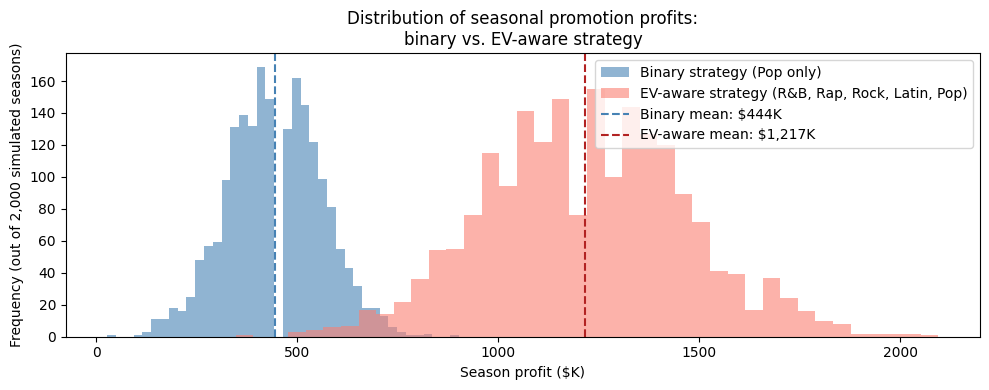

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(binary_profits, bins=40, alpha=0.6, color="steelblue", label="Binary strategy (Pop only)")
ax.hist(ev_profits, bins=40, alpha=0.6, color="salmon", label="EV-aware strategy (R&B, Rap, Rock, Latin, Pop)")

ax.axvline(binary_profits.mean(), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Binary mean: ${binary_profits.mean():,.0f}K")
ax.axvline(ev_profits.mean(), color="firebrick", linestyle="--", linewidth=1.5,
           label=f"EV-aware mean: ${ev_profits.mean():,.0f}K")

ax.set_xlabel("Season profit ($K)")
ax.set_ylabel("Frequency (out of 2,000 simulated seasons)")
ax.set_title("Distribution of seasonal promotion profits:\nbinary vs. EV-aware strategy")
ax.legend()
plt.tight_layout()
plt.show()

The two distributions barely overlap. In almost every simulated season, the EV-aware
strategy outperforms the binary strategy — not by luck, but because it runs four
additional EV-positive genres that binary thinking treats as "won't happen."

## 6. The certainty illusion

In [9]:
binary_genres = genre_stats[genre_stats["binary_runs"]]
actual_miss_rate = 1 - binary_genres["hit_rate"].values[0]  # only Pop passes the binary threshold

print(f"Genre binary strategy runs: {binary_genres['playlist_genre'].values}")
print(f"Pop hit rate: {binary_genres['hit_rate'].values[0]:.1%}")
print()
print(f"Binary thinking assumes: Pop campaigns succeed close to 100% of the time.")
print(f"Reality: Pop campaigns MISS {actual_miss_rate:.1%} of the time.")
print()
print(f"In a 100-campaign Pop season, expect roughly {actual_miss_rate * 100:.0f} misses.")

Genre binary strategy runs: <StringArray>
['pop']
Length: 1, dtype: str
Pop hit rate: 54.0%

Binary thinking assumes: Pop campaigns succeed close to 100% of the time.
Reality: Pop campaigns MISS 46.0% of the time.

In a 100-campaign Pop season, expect roughly 46 misses.


Even the one genre the binary strategy "bets on" fails almost half the time.
Binary thinking treats 54% as near-certainty — but 46 out of every 100 Pop
campaigns end in a miss. The binary strategy isn't avoiding uncertainty; it's
just *ignoring* it.

## 7. Takeaway

**What the simulation reveals:** Rounding a 46% probability to "won't happen"
isn't a conservative judgment — it's an expensive one. R&B carries a 37.2% hit
rate, well above the 34.8% break-even; skipping R&B entirely costs WaveForm
roughly $56K per season in foregone expected profit. Multiplied across R&B, Rap,
Rock, and Latin, binary thinking leaves around $770K on the table each season —
not because those genres are bad bets, but because a threshold of 50% has nothing
to do with the payoff math.

**The deeper lesson:** The 50% binary threshold wasn't chosen because it's the
economic break-even — it was chosen because "above 50% sounds like it'll work."
That's the bias this exercise is designed to reveal. A well-calibrated probability
estimate, however far from 50%, contains real information about expected outcomes.
Rounding it away discards that information entirely.

---
## Connecting forward: what this means for the Nimbus project

In the capstone project, you'll analyze a pricing decision for **Nimbus Streaming**,
a fictional 4M-subscriber video service. At every step of that analysis — estimating
churn probability from pilot data, computing expected revenue impact under different
price scenarios, running sensitivity tests — you'll be working with probability
estimates that sit in the same uncertain 30–60% range you just simulated.

The biases you quantified here don't disappear just because the analysis is more
sophisticated. An analyst who thinks "we have a 54% chance this price increase pays
off, so it'll pay off" is making the same mistake as WaveForm's editorial team.
The decision framework you'll build in the project exists precisely to avoid that:
to make recommendations that are grounded in the full uncertainty — the hit rate
*and* the miss rate — not a rounded-up certainty.